In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [7]:
#加载鸢尾花数据集
iris = datasets.load_iris()
x = iris.data
y = iris.target

In [8]:
#划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [9]:
#特征标准化
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
#用SVM训练
svm_model = SVC(random_state=0)
svm_model.fit(x_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [11]:
#预测与评估
y_pred = svm_model.predict(x_test_scaled)
accurracy = accuracy_score(y_test, y_pred)
print("Test Accuracy: ", accurracy)


Test Accuracy:  0.9777777777777777


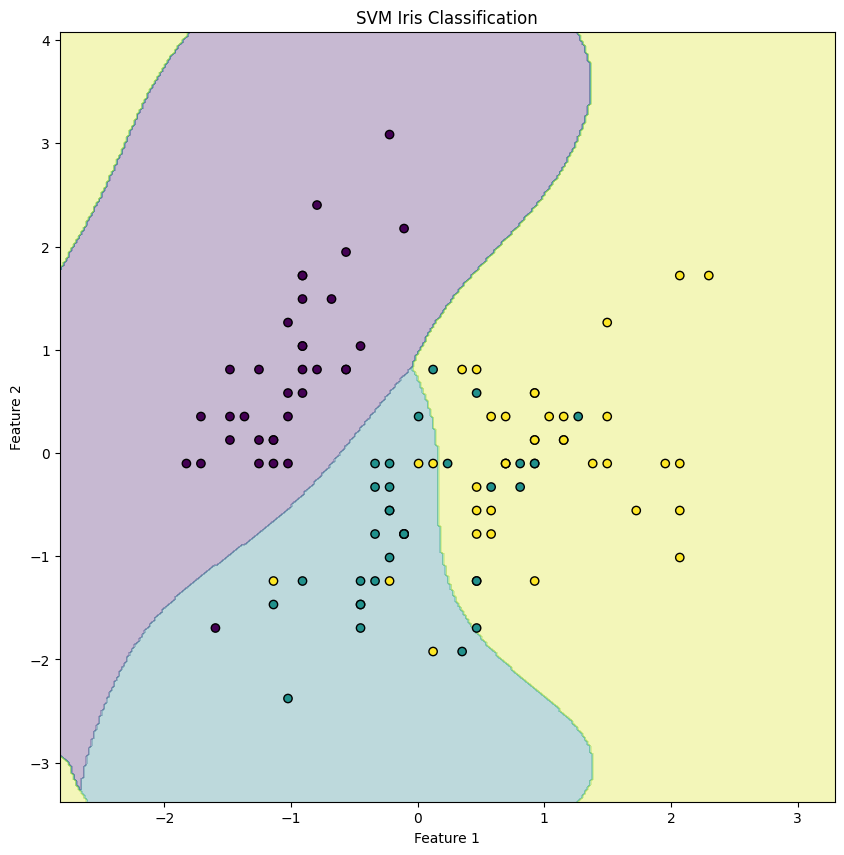

In [ ]:
#取前两个特征做二维分类可视化
x_2d = x[:, :2]
x_train_2d, x_test_2d, y_train_2d, y_test_2d = train_test_split(x_2d, y, test_size=0.3, random_state=0)
scaler2d = StandardScaler()
x_train_2d_scaled = scaler2d.fit_transform(x_train_2d)
x_test_2d_scaled = scaler2d.transform(x_test_2d)

svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_2d.fit(x_train_2d_scaled, y_train_2d)

#绘制边界
h = 0.02
x_min, x_max = x_train_2d_scaled[:, 0].min()-1, x_train_2d_scaled[:, 0].max()+1
y_min, y_max = x_train_2d_scaled[:, 1].min()-1, x_train_2d_scaled[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,10))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(x_train_2d_scaled[:,0], x_train_2d_scaled[:,1], c=y_train_2d, edgecolors='k')
plt.title("SVM Iris Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()